# KNN para Regresión: Predicción del precio de viviendas

Objetivo: comprender cómo funciona KNN antes de usarlo con Scikit-Larn.

## 1. Problema
Tenemos viviendas con precio conocido y queremos estimar el precio de una nueva vivienda.

In [1]:
import pandas as pd
from math import sqrt
casas=pd.DataFrame({
 'superficie':[80,90,100,120,140,160,180,200],
 'habitaciones':[2,2,3,3,3,4,4,5],
 'antiguedad':[25,20,18,15,10,8,5,3],
 'precio':[120,140,155,190,230,260,300,340]
})
casas

,superficie,habitaciones,antiguedad,precio
0,80,2,25,120
1,90,2,20,140
2,100,3,18,155
3,120,3,15,190
4,140,3,10,230
5,160,4,8,260
6,180,4,5,300
7,200,5,3,340


## 2. Cálculo manual de distancias

In [2]:
#queremos estimar el precio de esta vivienda
nueva={'superficie':150,'habitaciones':3,'antiguedad':9}

df=casas.copy()
df['distancia']=df.apply(lambda r:sqrt((r.superficie-150)**2+(r.habitaciones-3)**2+(r.antiguedad-9)**2),axis=1)
df.sort_values('distancia')

,superficie,habitaciones,antiguedad,precio,distancia
4,140,3,10,230,10.049876
5,160,4,8,260,10.099505
6,180,4,5,300,30.282008
3,120,3,15,190,30.594117
7,200,5,3,340,50.398413
2,100,3,18,155,50.803543
1,90,2,20,140,61.008196
0,80,2,25,120,71.812255


## 3. Predicción manual

In [3]:
k=3
vecinos=df.sort_values('distancia').head(k)
pred=vecinos['precio'].mean()
print(vecinos[['superficie','precio','distancia']])
print('Predicción:',pred)

   superficie  precio  distancia
4         140     230  10.049876
5         160     260  10.099505
6         180     300  30.282008
Predicción: 263.3333333333333


## 4. Verificación con Scikit-Learn

In [4]:
from sklearn.neighbors import KNeighborsRegressor
X=casas[['superficie','habitaciones','antiguedad']]
y=casas['precio']
m=KNeighborsRegressor(n_neighbors=3)
m.fit(X,y)
print(m.predict([[150,3,9]]))

[263.33333333]


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


## 5. Aplicación real: escalando la idea a un dataset más grande

Hasta acá calculamos todo **a mano** con 8 casas: la distancia, el ranking de vecinos y el promedio. Esa es la idea completa de KNN.

Ahora vamos a hacer dos cosas:

1. Ver **por qué es importante escalar los datos** antes de calcular distancias (la razón matemática detrás del paso "Escalado").
2. **Escalar el enfoque**: aplicar la misma idea con un dataset más grande (300 casas) y el flujo completo de Scikit-Learn (train/test, `Pipeline`, `GridSearchCV` y métricas).


### 5.1 ¿Por qué escalar antes de calcular la distancia?

En la Parte 2 calculamos la distancia usando `superficie`, `habitaciones` y `antiguedad` **tal cual**, sin transformarlas. El problema: `superficie` va de 80 a 200 (rango de 120), mientras que `habitaciones` va de 2 a 5 (rango de 3). Al estar en escalas tan distintas, `superficie` domina casi por completo el cálculo de la distancia, y `habitaciones` casi no influye.

Comparemos el ranking de vecinos **sin escalar** (el que ya calculamos) contra el ranking **escalando** las variables con `StandardScaler`, que las deja a todas con media 0 y desvío 1.


In [5]:
from sklearn.preprocessing import StandardScaler

print("Ranking de vecinos SIN escalar (Parte 2):")
print(df.sort_values('distancia')[['superficie', 'habitaciones', 'antiguedad', 'precio', 'distancia']])

# Escalamos las mismas 8 casas
scaler_demo = StandardScaler()
casas_features = casas[['superficie', 'habitaciones', 'antiguedad']]
casas_scaled = pd.DataFrame(
    scaler_demo.fit_transform(casas_features),
    columns=['superficie', 'habitaciones', 'antiguedad']
)

# Escalamos la casa nueva con el mismo scaler (¡nunca con uno nuevo!)
nueva_df = pd.DataFrame([nueva])
nueva_scaled = scaler_demo.transform(nueva_df)[0]

casas_scaled['distancia'] = casas_scaled.apply(
    lambda r: sqrt(
        (r.superficie - nueva_scaled[0]) ** 2
        + (r.habitaciones - nueva_scaled[1]) ** 2
        + (r.antiguedad - nueva_scaled[2]) ** 2
    ),
    axis=1
)
casas_scaled['precio'] = casas['precio'].values

print()
print("Ranking de vecinos ESCALANDO las variables:")
print(casas_scaled.sort_values('distancia')[['superficie', 'habitaciones', 'antiguedad', 'precio', 'distancia']])


Ranking de vecinos SIN escalar (Parte 2):
   superficie  habitaciones  antiguedad  precio  distancia
4         140             3          10     230  10.049876
5         160             4           8     260  10.099505
6         180             4           5     300  30.282008
3         120             3          15     190  30.594117
7         200             5           3     340  50.398413
2         100             3          18     155  50.803543
1          90             2          20     140  61.008196
0          80             2          25     120  71.812255

Ranking de vecinos ESCALANDO las variables:
   superficie  habitaciones  antiguedad  precio  distancia
4    0.152783     -0.258199   -0.414039     230   0.280722
5    0.641689      0.774597   -0.690066     260   1.070267
3   -0.336123     -0.258199    0.276026     190   1.106133
6    1.130595      0.774597   -1.104105     300   1.381754
2   -0.825029     -0.258199    0.690066     155   1.742638
1   -1.069482     -1.290994 

**Qué mirar:** compará el orden de las filas (el ranking) en las dos tablas. Verás que, si bien los puntos son los mismos, sus **distancias relativas cambian significativamente** al ser escalados. Esto significa que diferentes casas pueden ser consideradas las "más cercanas" en el espacio escalado. Si el conjunto de vecinos más cercanos cambia, la predicción final también puede variar. Por eso, el escalado no es un detalle técnico solamente: puede cambiar directamente la predicción final.

De acá en adelante, **siempre vamos a escalar antes de entrenar KNN** para asegurar que todas las características contribuyan de manera equitativa al cálculo de la distancia.

### Visualización del impacto del escalado

Para entender mejor cómo el escalado afecta la distribución de los datos, visualicemos las variables `superficie` y `antiguedad` antes y después de aplicar `StandardScaler`.

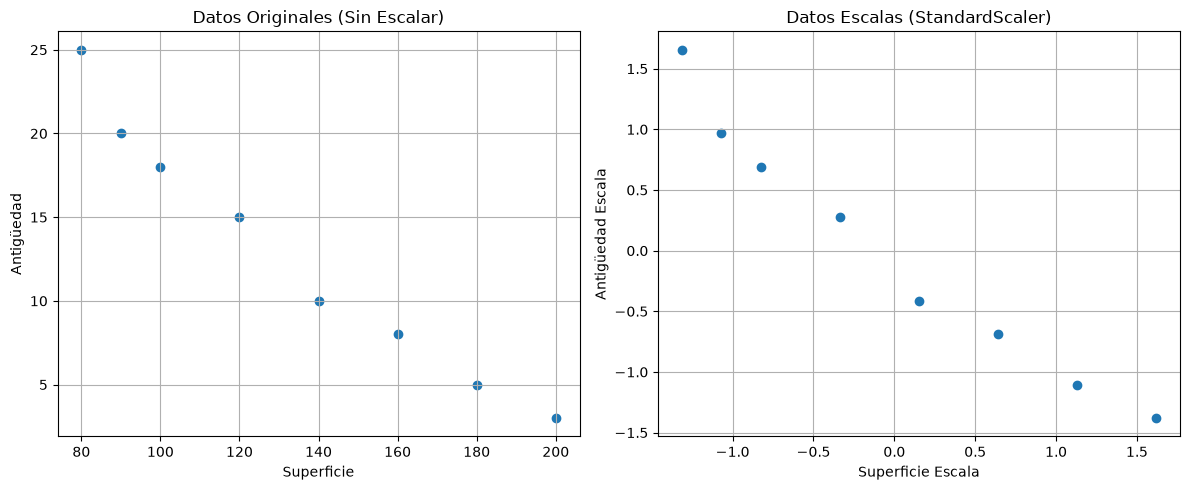

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Subplot para datos sin escalar
plt.subplot(1, 2, 1)
plt.scatter(casas['superficie'], casas['antiguedad'])
plt.title('Datos Originales (Sin Escalar)')
plt.xlabel('Superficie')
plt.ylabel('Antigüedad')
plt.grid(True)

# Subplot para datos escalados
plt.subplot(1, 2, 2)
plt.scatter(casas_scaled['superficie'], casas_scaled['antiguedad'])
plt.title('Datos Escalas (StandardScaler)')
plt.xlabel('Superficie Escala')
plt.ylabel('Antigüedad Escala')
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.2 Generamos un dataset más grande

Con 8 casas alcanza para entender la idea, pero no para evaluar un modelo en serio. Generamos un dataset sintético de 300 casas, con una relación realista entre las variables y el precio, más un poco de ruido aleatorio.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 300

superficie_g = np.random.uniform(50, 250, n_samples)
habitaciones_g = np.random.randint(1, 6, n_samples)
antiguedad_g = np.random.uniform(0, 40, n_samples)

# Precio con un componente determinista + ruido gaussiano
precio_g = (
    (superficie_g * 1.5)
    + (habitaciones_g * 12)
    - (antiguedad_g * 1.8)
    + np.random.normal(0, 15, n_samples)
    + 40
)

dataset_real = pd.DataFrame({
    'superficie': superficie_g,
    'habitaciones': habitaciones_g,
    'antiguedad': antiguedad_g,
    'precio': precio_g
})

dataset_real.head()


,superficie,habitaciones,antiguedad,precio
0,124.908024,5,22.763259,262.164922
1,240.142861,4,2.540473,439.930924
2,196.398788,3,1.472875,366.964848
3,169.731697,4,5.354085,345.071453
4,81.203728,5,0.546879,233.429119


### 5.3 Train/Test, Pipeline con escalado y búsqueda de hiperparámetros

Tres ideas nuevas acá:

- **Train/Test split**: entrenamos con una parte de los datos y evaluamos con casas que el modelo nunca vio.
- **`Pipeline`**: encadena el `StandardScaler` y el `KNeighborsRegressor` en un solo objeto. Esto evita un error muy común (*data leakage*): el escalador se ajusta *solo* con los datos de entrenamiento, nunca con los de test.
- **`GridSearchCV`**: en vez de elegir `k` a mano probando valores uno por uno (como haríamos manualmente), le pedimos a Scikit-Learn que pruebe automáticamente varias combinaciones de `k`, tipo de peso y métrica de distancia, y se quede con la mejor usando validación cruzada.


In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_real = dataset_real[['superficie', 'habitaciones', 'antiguedad']]
y_real = dataset_real['precio']

X_train, X_test, y_train, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

# Pipeline: escalado + KNN, para evitar fuga de datos (data leakage)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Espacio de búsqueda de hiperparámetros
param_grid = {
    'knn__n_neighbors': range(1, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")


Mejores hiperparámetros encontrados:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}


### 5.4 Evaluar el modelo en el conjunto de prueba

Igual que antes con el cálculo manual, medimos qué tan lejos están las predicciones de los precios reales, pero ahora con métricas estándar:

- **MAE**: error absoluto promedio, en las mismas unidades que el precio.
- **RMSE**: parecido al MAE, pero penaliza más los errores grandes.
- **R²**: qué proporción de la variación del precio explica el modelo (1.0 es perfecto).


In [9]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN (Test) ===")
print(f"MAE  (Error Absoluto Medio): ${mae:.2f}k USD")
print(f"RMSE (Raíz del Error Cuadrático Medio): ${rmse:.2f}k USD")
print(f"R²   (Coeficiente de Determinación): {r2:.4f}")


=== MÉTRICAS DE EVALUACIÓN (Test) ===
MAE  (Error Absoluto Medio): $15.81k USD
RMSE (Raíz del Error Cuadrático Medio): $19.81k USD
R²   (Coeficiente de Determinación): 0.9497


### 5.5 Visualizar: valores reales vs. predicciones

Cuanto más cerca estén los puntos de la línea diagonal (predicción perfecta), mejor está prediciendo el modelo.


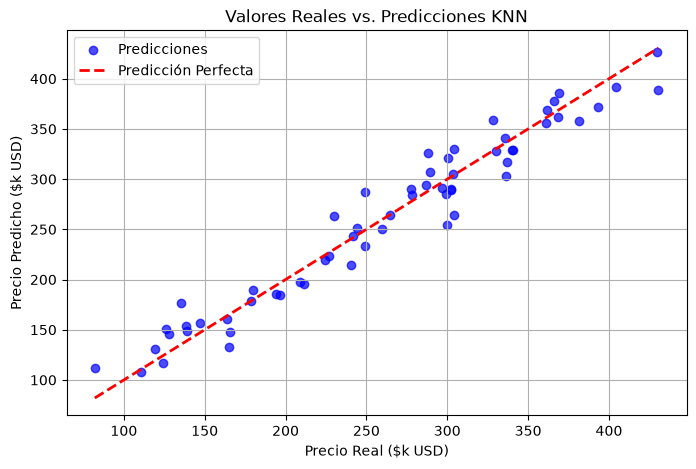

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='b', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.title('Valores Reales vs. Predicciones KNN')
plt.xlabel('Precio Real ($k USD)')
plt.ylabel('Precio Predicho ($k USD)')
plt.legend()
plt.grid(True)
plt.show()


### 5.6 Conclusión

- La idea de fondo de KNN es la misma en las 5 partes de este notebook: **buscar los vecinos más parecidos y promediar sus precios**. Lo que cambia es la escala del problema.
- **Escalar los datos no es un detalle técnico menor**: puede cambiar qué vecinos se consideran "cercanos", y por lo tanto, la predicción final.
- Un `Pipeline` con `GridSearchCV` automatiza lo que hicimos a mano en la Parte 3 (elegir vecinos y promediar), pero además busca automáticamente el mejor valor de `k` y otros hiperparámetros, usando validación cruzada en vez de una sola casa de prueba.
